## Introduction

The Quantum Generative Adversarial Network (QGAN) [[1]](https://github.com/Qiskit/textbook/blob/main/notebooks/quantum-machine-learning/qgan.ipynb)  [[2]](https://arxiv.org/abs/1406.2661) we propose consists of two Quantum Neural Network (QNN) [[3]](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html): a generator and a discriminator. The generator is responsible for creating synthetic data samples. The discriminator evaluates the authenticity of the created samples by distinguishing between real and generated data. Through an adversarial training process, both networks continuously improve, leading to the generation of increasingly realistic data. 
This fully quantum approach benefits from the strengths of quantum state preparation and gradient calculation combined with classical optimizators [[4]](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
The data used to train the QGAN in this implementation is a probability distributions.

This implementation uses aer_simulator_statevector.

## Implementation (statevector simulation)

In [1]:
#--- INSTALATION INSTRUCTIONS ---#

# For linux 64-bit systems,
#uname -a

# Conda quick installation
#mkdir -p ~/miniconda3
#wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
#bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
#rm ~/miniconda3/miniconda.sh

# Create enviroment with conda
#conda create -n myenv python=3.10
#conda activate myenv
#pip install qiskit==1.4.5 qiskit-machine-learning==0.8.4 'qiskit-machine-learning[sparse]' torch matplotlib pylatexenc ipykernel
# IMPORTANT: Make sure you are on 3.10
# May need to restart the kernel after instalation

#--- Imports ---#
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, random_statevector
from qiskit.visualization import plot_histogram
from qiskit import qpy

import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
#- Visualization configuration -#

folder = "data/noiseless_torch_opt_amp/noiseless_simulation/q4/seed1/" # "data/fullyq_torch/sim/q4/seed1/"

# Visualization configuration dict
visual_config = {
    'train': False,
    'draw_circuits': True,
    'draw_images': True,
    'draw_probs': True,
    'draw_results': True,
    'circuits_file': folder + 'circuits.qpy',
    'dataset_file': folder + 'dataset.npy',
    'training_data_file': folder + 'training_data.pth',
}

In [3]:
#- Get training data -#
if visual_config['train']:
    ! python3 sim_torchc.py --n_qubits 4

In [4]:
#- Load data -#

# Load dataset
X = np.load(visual_config['dataset_file'])

# Load circuits    
with open(visual_config['circuits_file'], 'rb') as fd:
    circuits = qpy.load(fd)
    
real_circuits = circuits[:(len(circuits)-3)]
randomizer_circuit = circuits[-3]
generator_circuit = circuits[-2]
discriminator_circuit = circuits[-1]
print(len(circuits))


# Load training data
params = torch.load(visual_config['training_data_file'], weights_only=False)

10


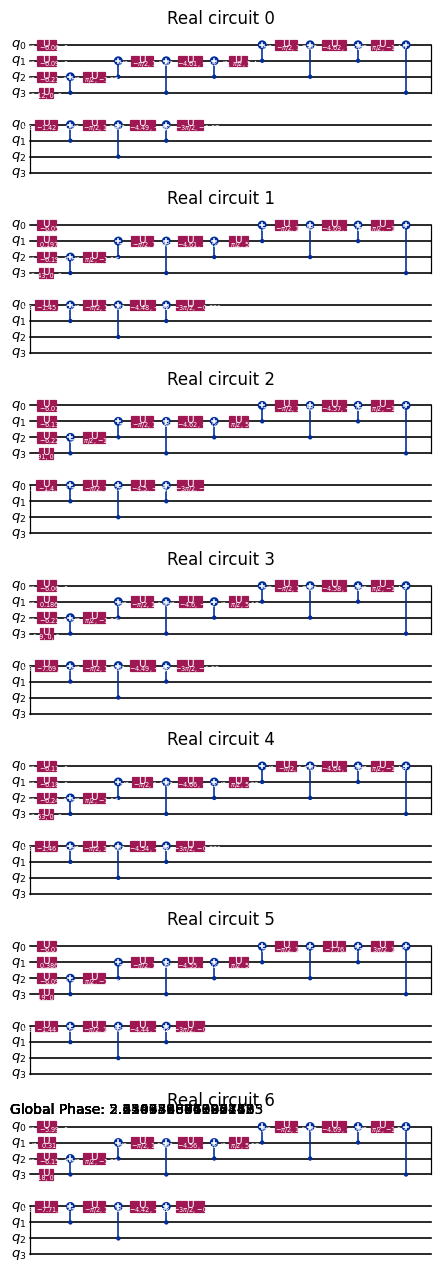

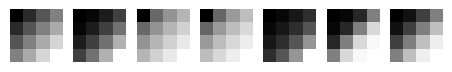

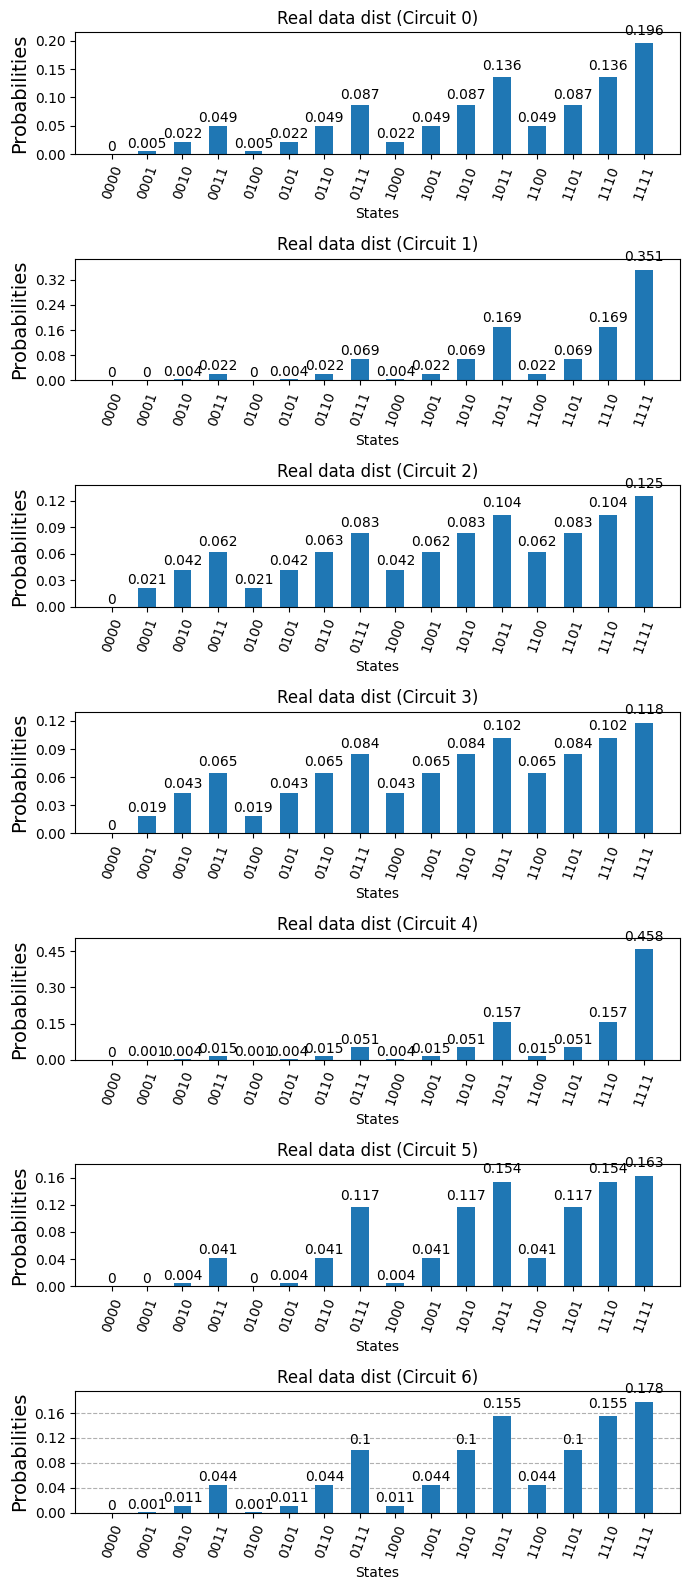

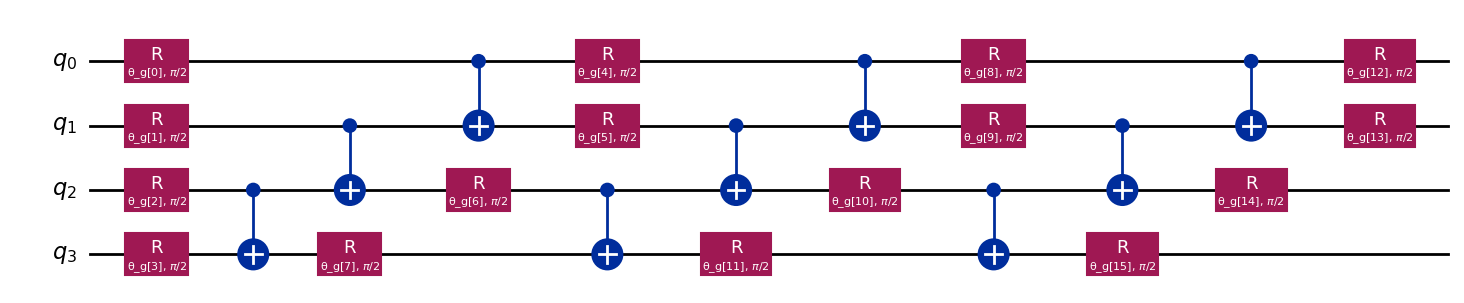

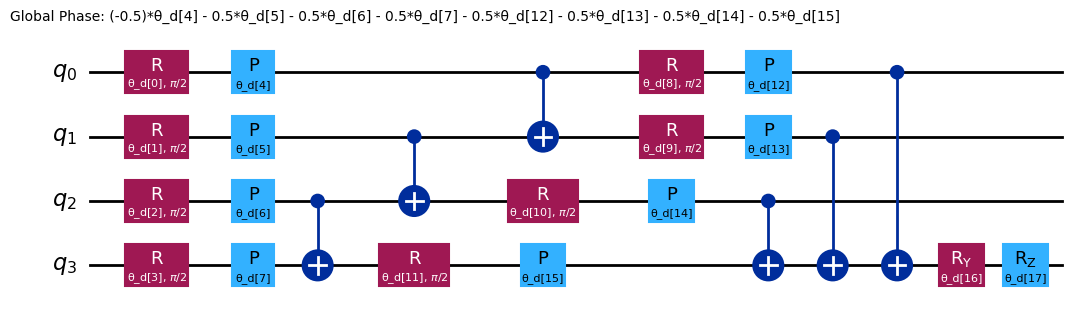

[-0.05195893  0.03687591 -0.22595155 -0.18968843  0.18896339  0.29421743
 -0.11722905  0.12083986  0.23649228  0.24793868 -0.26072441 -0.28962042
 -0.20745167  0.23759394 -0.25236613 -0.04956954  0.28770048  0.02083836]


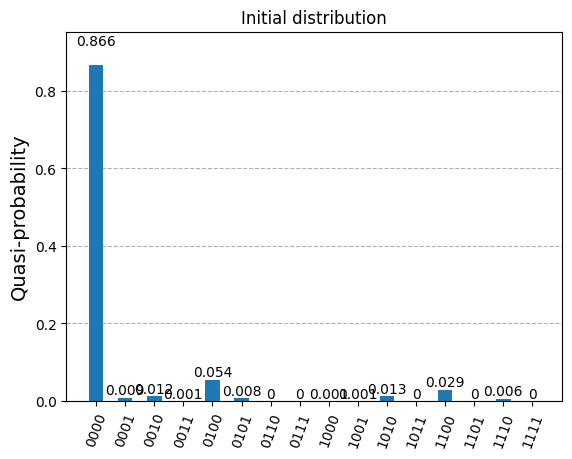

In [5]:
#- Circuits visualization -#

# Real data circuits
if visual_config['draw_circuits']:
    fig, axes = plt.subplots(len(real_circuits), figsize=(2 * len(real_circuits), 16))
    if len(real_circuits) == 1: axes = [axes]
    for i, real_circuit in enumerate(real_circuits):
        real_circuit.decompose(reps=5).draw('mpl', ax=axes[i])
        axes[i].set_title(f"Real circuit {i}")
    plt.show()

# Real data images
if visual_config['draw_images']:
    for i in range(len(real_circuits)):
        plt.subplot(1,len(X)+1,i+1)
        plt.imshow(X[i], cmap="gray")
        plt.axis("off")
    plt.show()

# Real data circuit probability distribution
if visual_config['draw_probs']:
    n_qubits = generator_circuit.num_qubits
    def prepare_dicts(dicts):
        for dict in dicts:
            for n in range(2**n_qubits):
                key = format(n, 'b').zfill(n_qubits)
                if key not in dict.keys():
                    dict[key] = 0.0


    fig, axes = plt.subplots(len(real_circuits), figsize=(1 * len(real_circuits), 16))
    if len(real_circuits) == 1: axes = [axes]
    for i, real_circuit in enumerate(real_circuits):
        real_prob_dict = Statevector(real_circuit).probabilities_dict()
        prepare_dicts([real_prob_dict])
        plot_histogram(real_prob_dict, ax=axes[i])
        
        axes[i].set_title(f"Real data dist (Circuit {i})")
        axes[i].set_xlabel("States")
        axes[i].set_ylabel("Probabilities")
    plt.tight_layout()
    plt.show()


# Generator circuit
if visual_config['draw_circuits']:
    display(generator_circuit.draw('mpl'))

# Generator initial probability distribution
if visual_config['draw_probs']:
    init_gen_circuit = generator_circuit.assign_parameters(params['init_gen_params'])
    init_prob_dict = Statevector(init_gen_circuit).probabilities_dict()
    fig, ax1 = plt.subplots(1, 1, sharey=True)
    ax1.set_title("Initial distribution")
    plot_histogram(init_prob_dict, ax=ax1)


# Discriminator circuit
if visual_config['draw_circuits']:
    display(discriminator_circuit.draw('mpl'))

# Discriminator initial parameters
print(params['init_disc_params'])

Training complete: data/noiseless_torch_opt_amp/noiseless_simulation/q4/seed1/training_data.pth 
Best Evaluation: 0.0014173512800661695 in epoch 857 
Improvement: 0.07603464230485216


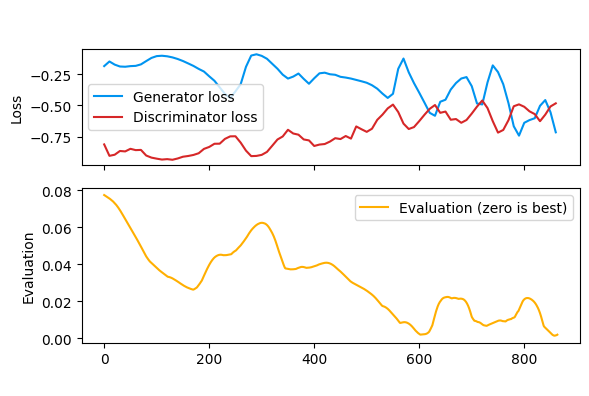

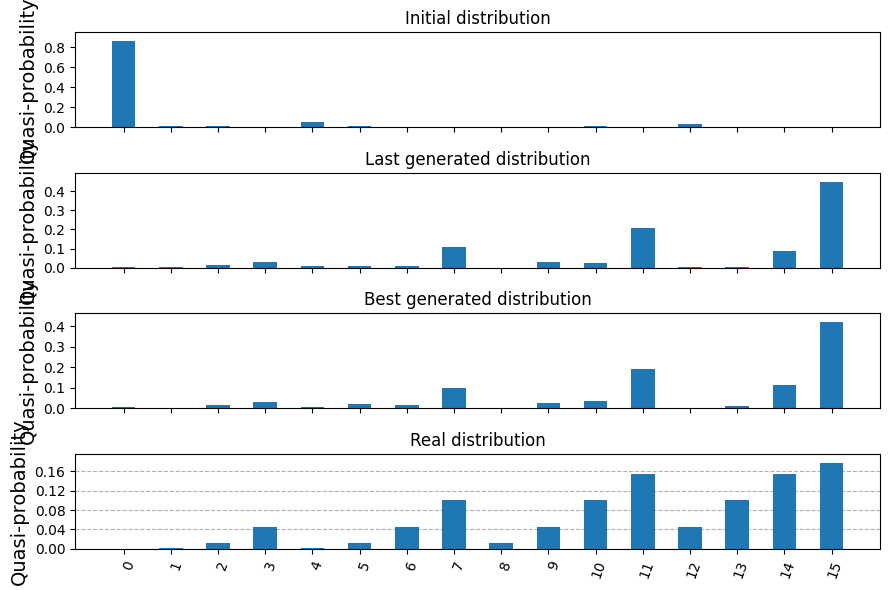

In [6]:
#- Training visualizartion -#

# Visualize training progress
if visual_config['draw_results']:
        gloss = params['metrics']['gloss']
        dloss = params['metrics']['dloss']
        eval = params['metrics']['eval']

        gloss_ax = list(gloss.keys())
        gloss_data = list(gloss.values())
        dloss_ax = list(dloss.keys())
        dloss_data = list(dloss.values())
        eval_ax = list(eval.keys())
        eval_data = list(eval.values())

        fig, (loss, kl) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [0.75, 1]}, figsize=(6,4))
        fig.suptitle('QGAN training stats', color="#ffffffff")
        kl.set_xlabel("Epochs", color="#ffffffff")
        loss.plot(gloss_ax, gloss_data, label="Generator loss", color="#0094f0ff")
        loss.plot(dloss_ax, dloss_data, label="Discriminator loss", color="C3")
        loss.legend()
        loss.set(ylabel='Loss')
        kl.plot(eval_ax, eval_data, label="Evaluation (zero is best)", color="#ffaf01ff")
        kl.set(ylabel='Evaluation')
        kl.legend()
        fig.tight_layout()

        print("Training complete:", visual_config['training_data_file'], "\nBest Evaluation:", np.min(eval_data), "in epoch", np.argmin(eval_data), "\nImprovement:", eval_data[0]-np.min(eval_data))



# Analyze generator circuit with new parameters
if visual_config['draw_results'] and visual_config['draw_probs']:
    dict1 = Statevector(generator_circuit.assign_parameters(params['init_gen_params'])).probabilities_dict()
    dict2 = Statevector(generator_circuit.assign_parameters(params['gen_params'].detach().numpy())).probabilities_dict()
    dict3 = Statevector(generator_circuit.assign_parameters(params['best_gen_params'])).probabilities_dict()
    dict4 = Statevector(real_circuit).probabilities_dict()
    
    n_qubits = generator_circuit.num_qubits
    def prepare_dicts(dicts):
        for dict in dicts:
            for n in range(2**n_qubits):
                key = format(n, 'b').zfill(n_qubits)
                if key not in dict.keys():
                    dict[n] = 0.0
                else:
                    dict[n] = dict[key]
                    del dict[key]
        

    prepare_dicts([dict1, dict2, dict3, dict4])

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharey=False, sharex=True, figsize=(9,6))
    
    ax1.set_ylabel('Probabilities')
    ax1.set_title("Initial distribution")
    ax2.set_title("Last generated distribution")
    ax3.set_title("Best generated distribution")
    ax4.set_title("Real distribution")
    plot_histogram(dict1, ax=ax1, bar_labels=False)
    plot_histogram(dict2, ax=ax2, bar_labels=False)
    plot_histogram(dict3, ax=ax3, bar_labels=False)
    plot_histogram(dict4, ax=ax4, bar_labels=False)
    fig.tight_layout()

    plt.show()

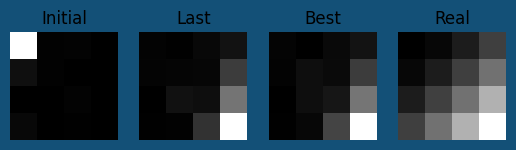

In [7]:
# Visualize results images
if  visual_config['draw_results'] and visual_config['draw_images']:
    def create_ran_generator(generator_circuit):
        n_qubits = generator_circuit.num_qubits

        sv = random_statevector(2**n_qubits)
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(sv, qc.qubits, normalize=True) 

        random_input_circuit = qc

        # Connect random circuit with generator
        ran_gen_circuit = QuantumCircuit(n_qubits)
        ran_gen_circuit.compose(random_input_circuit, inplace=True)
        ran_gen_circuit.compose(generator_circuit, inplace=True)
        
        return ran_gen_circuit
         
    randomness = False
    if randomness:
        ran_gen_circuit = create_ran_generator(generator_circuit)
    else:
        ran_gen_circuit = generator_circuit

    probs1 = np.array(Statevector(ran_gen_circuit.assign_parameters(params['init_gen_params'])).probabilities()).reshape(X.shape[1:3])
    probs2 = np.array(Statevector(ran_gen_circuit.assign_parameters(params['gen_params'].detach().numpy())).probabilities()).reshape(X.shape[1:3])
    probs3 = np.array(Statevector(ran_gen_circuit.assign_parameters(params['best_gen_params'])).probabilities()).reshape(X.shape[1:3])
    probs4 = np.array(Statevector(real_circuits[0]).probabilities()).reshape(X.shape[1:3])

    plt.subplot(1,4,1)
    plt.imshow(probs1, cmap="gray")
    plt.axis("off")
    plt.title("Initial")
    
    plt.subplot(1,4,2)
    plt.imshow(probs2, cmap="gray")
    plt.axis("off")
    plt.title("Last")

    plt.subplot(1,4,3)
    plt.imshow(probs3, cmap="gray")
    plt.axis("off")
    plt.title("Best")

    plt.subplot(1,4,4)
    plt.imshow(probs4, cmap="gray")
    plt.axis("off")
    plt.title("Real")

    plt.gca().set_facecolor("#135077ff")

    # Optionally set the overall figure background to black
    plt.gcf().patch.set_facecolor("#135077ff")
    
    plt.show()